In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [58]:
# 1. Load the dataset (Source: World_Development_Indicators.xlsx.csv)
df = pd.read_csv('World_Development_Indicators.xlsx.csv').replace('..', np.nan)


In [60]:
df.head(5)

,Country Name,Country Code,Series Name,Series Code,2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023],2024 [YR2024],2025 [YR2025]
0,India,IND,Individuals using the Internet (% of population),IT.NET.USER.ZS,16.5,18.20000076,20.08130004,29.52350044,43.40544313,49.2580986,55.9,60.25230026,64.9434967,70
1,India,IND,"Educational attainment, at least Bachelor's or...",SE.TER.CUAT.BA.ZS,10.14317036,NaN,10.7825098,12.01603985,12.22344971,NaN,12.14107037,14.87930012,NaN,NaN
2,India,IND,Access to electricity (% of population),EG.ELC.ACCS.ZS,89.6,91.8,95.7,95.9,96.5,99.6,99.2,99.5,NaN,NaN
3,United States,USA,Individuals using the Internet (% of population),IT.NET.USER.ZS,85.54442129,87.27488917,88.49890317,89.43028486,90.34470367,91.2684021,92.72850037,93.52559662,94.69380188,NaN
4,United States,USA,"Educational attainment, at least Bachelor's or...",SE.TER.CUAT.BA.ZS,33.43968964,32.01588058,34.99246979,36.05515315,37.52428818,35.04922867,37.661129,38.60113144,39.05939102,NaN


In [78]:
# Reshape: Pivot indicators from rows into columns
# Defining the columns for the years available in your source [2]
year_cols = ['2016 [YR2016]', '2017 [YR2017]', '2018 [YR2018]', '2019 [YR2019]', 
             '2020 [YR2020]', '2021 [YR2021]', '2022 [YR2022]', '2023 [YR2023]']

df_melted = df_raw.melt(id_vars=['Country Name', 'Series Name'], 
                        value_vars=year_cols, var_name='Year', value_name='Value')

df_pivot = df_melted.pivot_table(index=['Country Name', 'Year'], 
                                 columns='Series Name', 
                                 values='Value', 
                                 aggfunc='first').reset_index()



In [80]:
# defining target and features
target = 'Individuals using the Internet (% of population)'
features = [
    'Access to electricity (% of population)',
    "Educational attainment, at least Bachelor's or equivalent, population 25+, total (%) (cumulative)"
]



In [82]:
# Clean Data  
df_pivot[features + [target]] = df_pivot[features + [target]].apply(pd.to_numeric, errors='coerce')
df_final = df_pivot.dropna(subset=[target])  # Convert to numeric and fill missing education values with column mean
X = df_final[features].fillna(df_final[features].mean())
y = df_final[target]



In [88]:
#  Linear Regression 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

Digital Inequality Model R-squared: 0.84


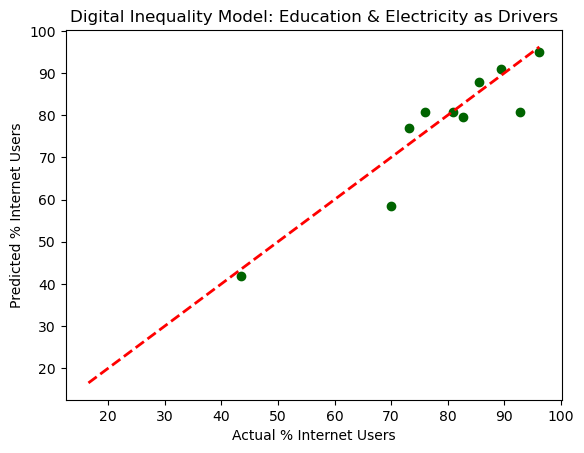

In [90]:
#  Visualisation and prediction
y_pred = model.predict(X_test)
print(f"Digital Inequality Model R-squared: {r2_score(y_test, y_pred):.2f}")

plt.scatter(y_test, y_pred, color='darkgreen')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual % Internet Users')
plt.ylabel('Predicted % Internet Users')
plt.title('Digital Inequality Model: Education & Electricity as Drivers')
plt.show()